<a href="https://colab.research.google.com/github/Abdil2146/tugas-data-science-kelompok/blob/main/Tugas_Final_FSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

import joblib

import warnings
warnings.filterwarnings("ignore")

In [61]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [62]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [63]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 1025
Jumlah Kolom : 14


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [65]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [66]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [67]:
print("Jumlah Data Duplikat :", df.duplicated().sum())

Jumlah Data Duplikat : 723


In [68]:
df = df.drop_duplicates()

print(df.shape)

(302, 14)


In [69]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0
878,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


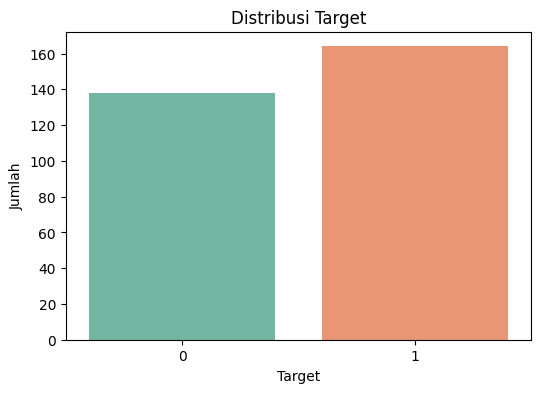

In [70]:
# ==========================================
# DISTRIBUSI TARGET
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df, palette='Set2')

plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Jumlah")

plt.show()

In [71]:
(df['target'].value_counts(normalize=True)*100).round(2)

,proportion
target,
1,54.3
0,45.7


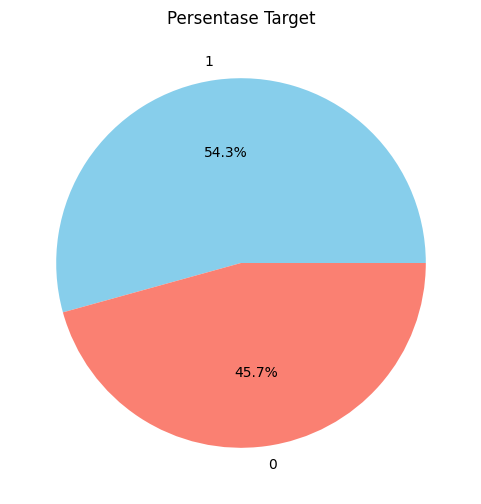

In [72]:
plt.figure(figsize=(6,6))

df['target'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','salmon']
)

plt.ylabel("")
plt.title("Persentase Target")

plt.show()

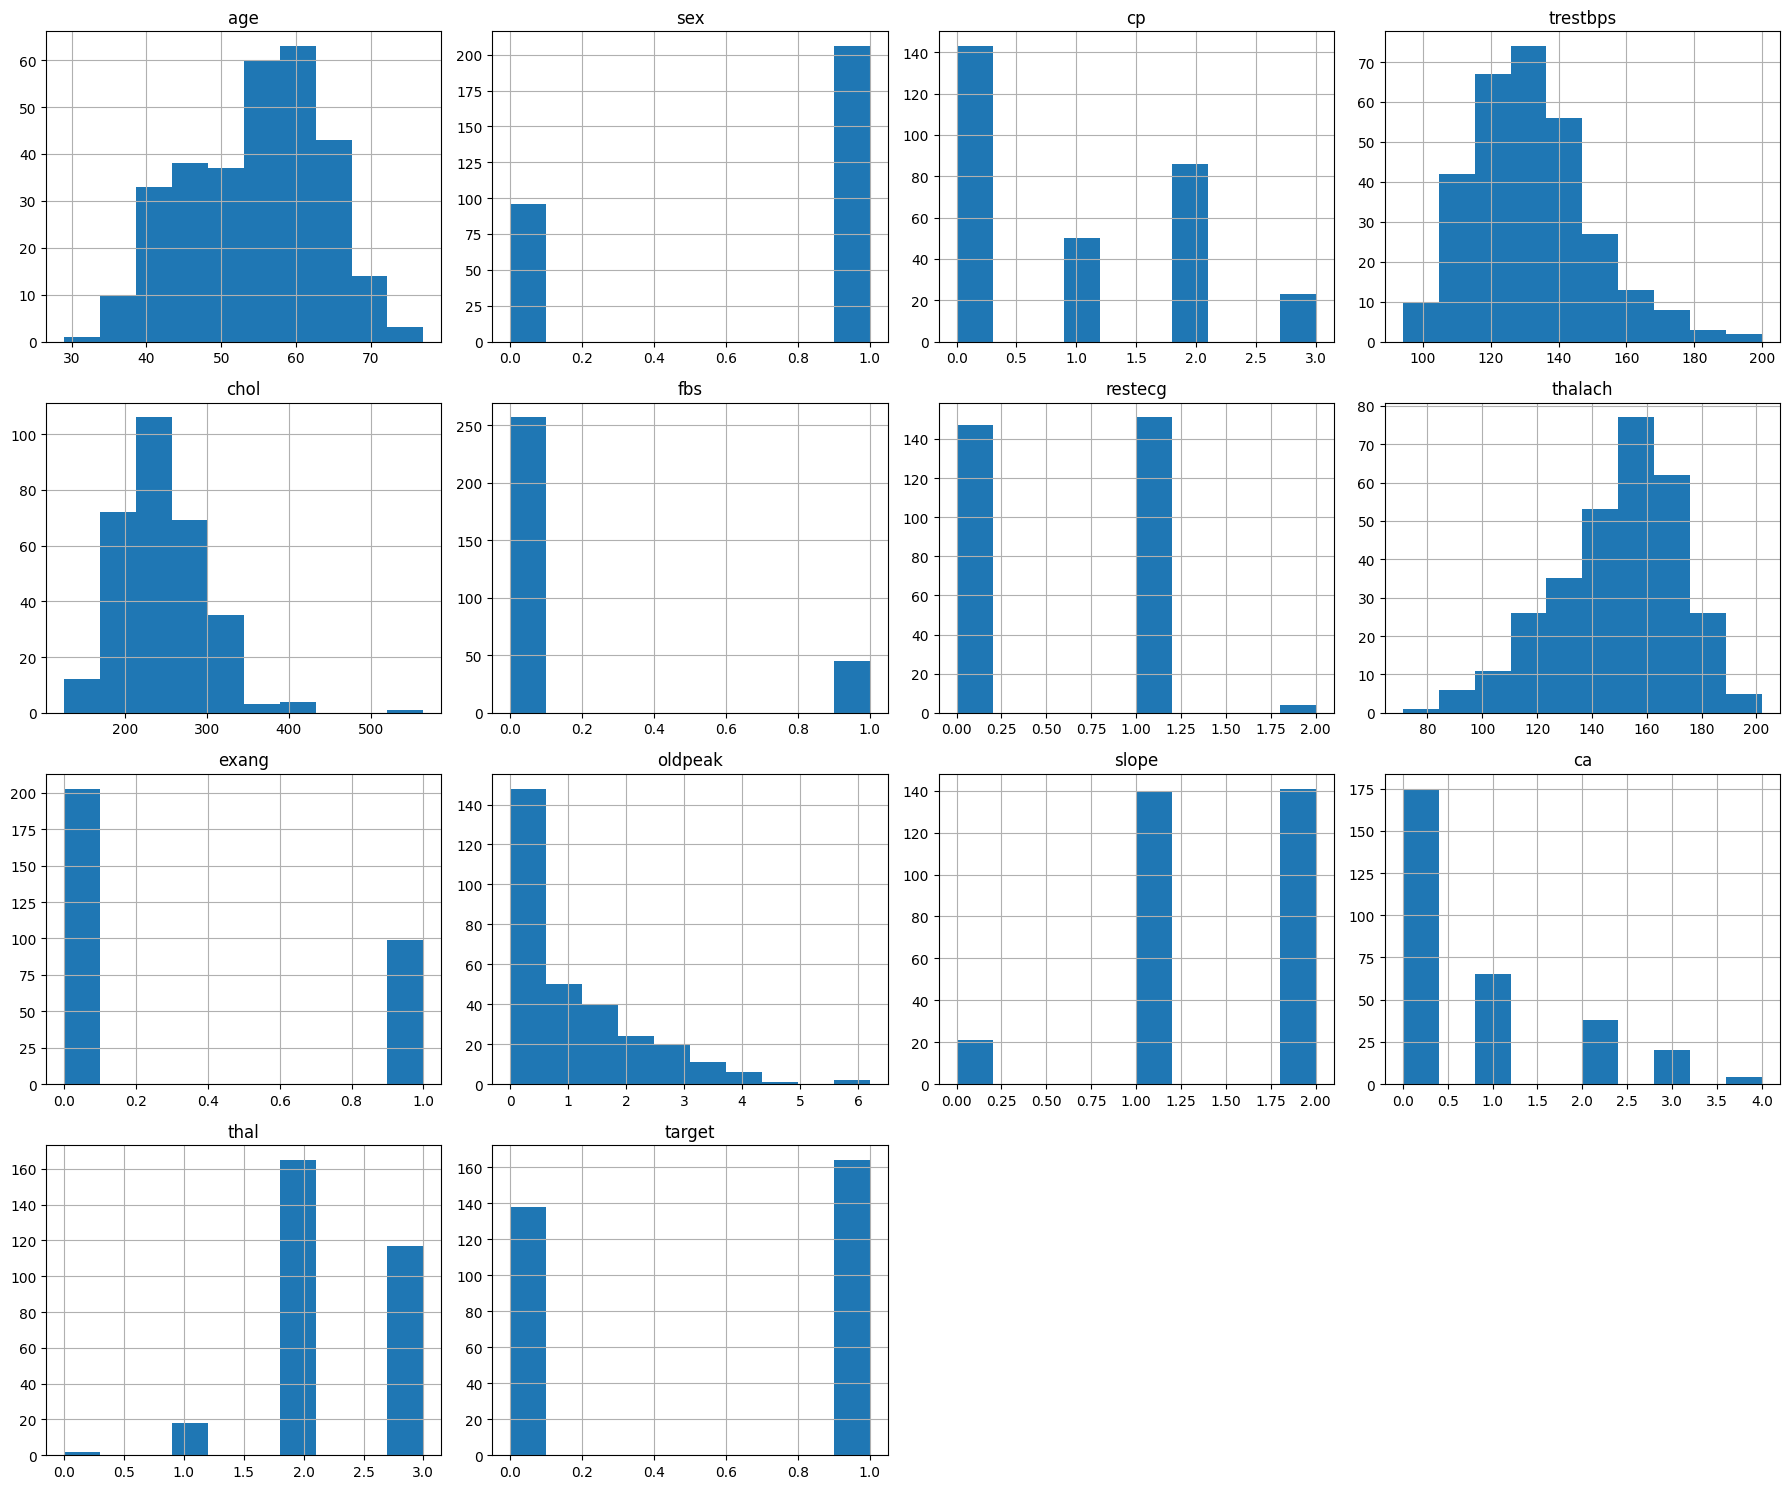

In [73]:
df.hist(figsize=(18,15))

plt.tight_layout()

plt.show()

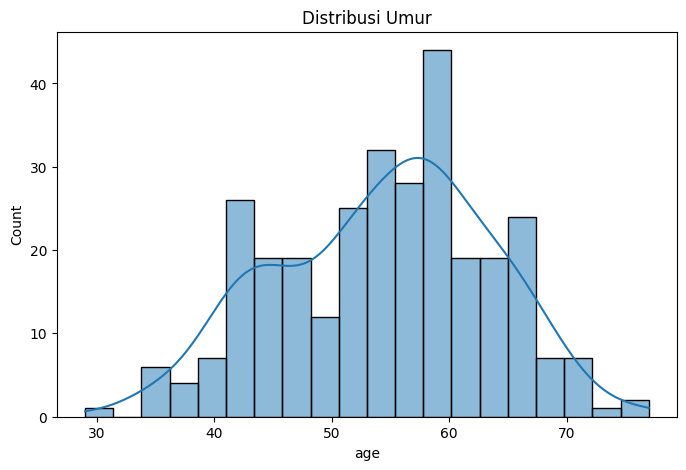

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Distribusi Umur")

plt.show()

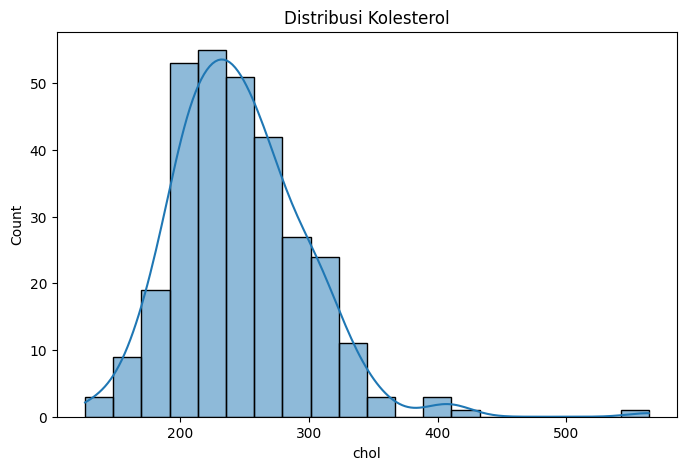

In [75]:
plt.figure(figsize=(8,5))

sns.histplot(df['chol'], bins=20, kde=True)

plt.title("Distribusi Kolesterol")

plt.show()

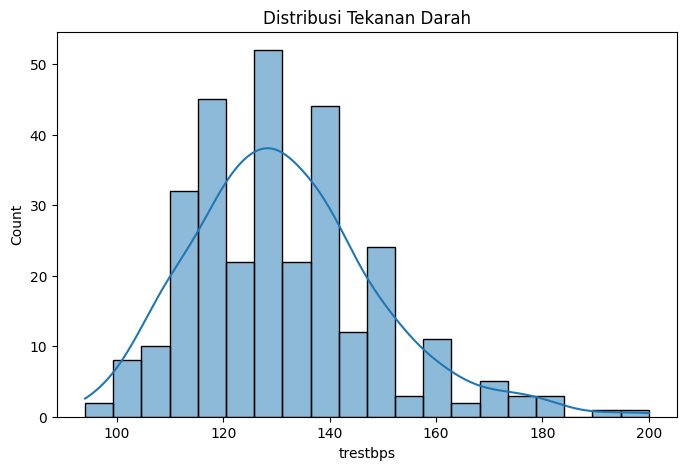

In [76]:
plt.figure(figsize=(8,5))

sns.histplot(df['trestbps'], bins=20, kde=True)

plt.title("Distribusi Tekanan Darah")

plt.show()

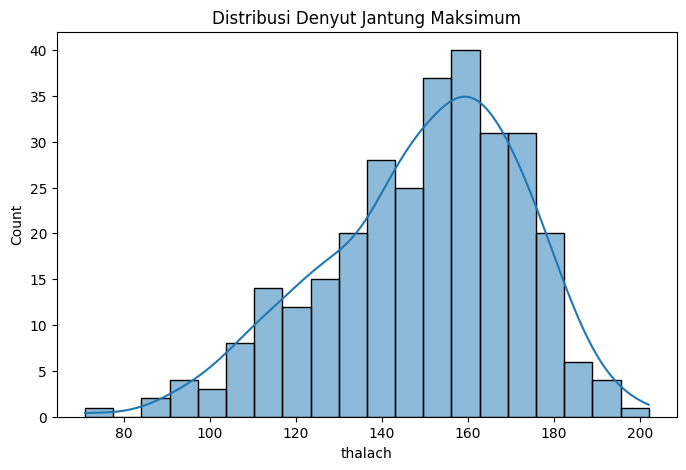

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(df['thalach'], bins=20, kde=True)

plt.title("Distribusi Denyut Jantung Maksimum")

plt.show()

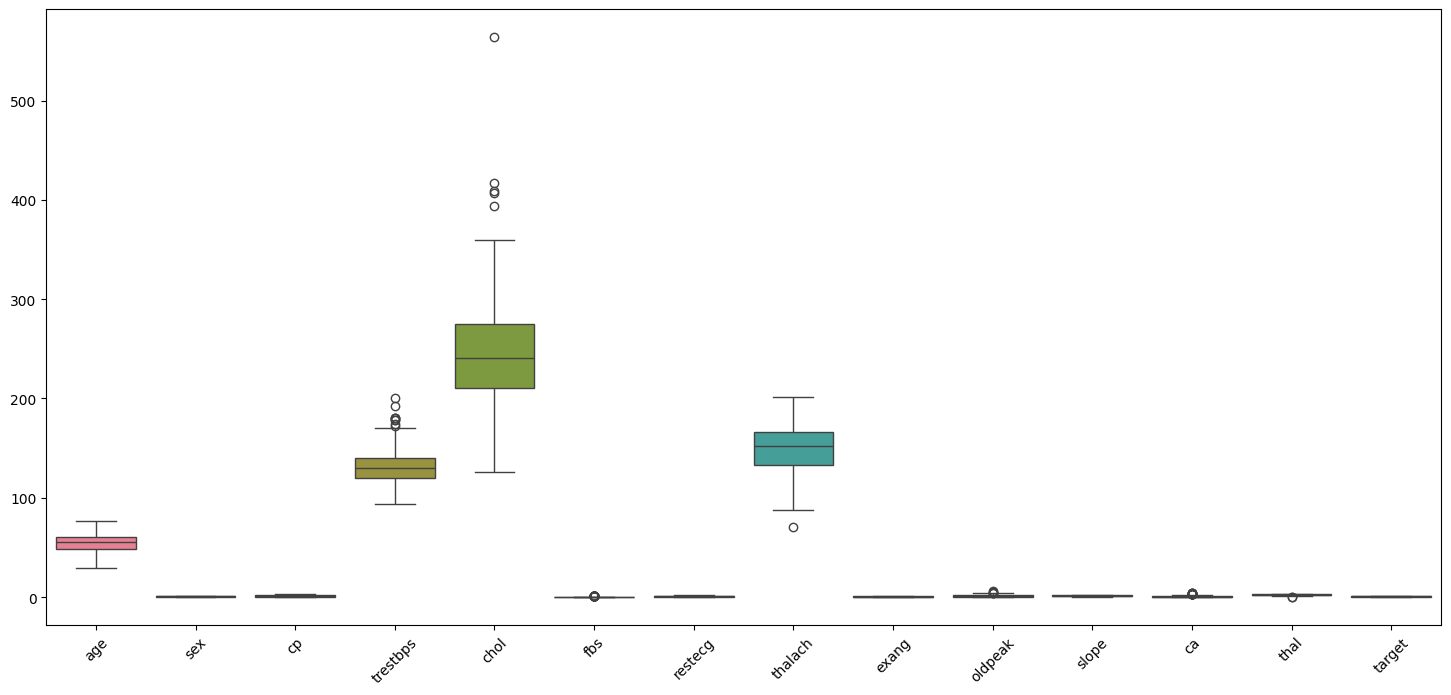

In [78]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

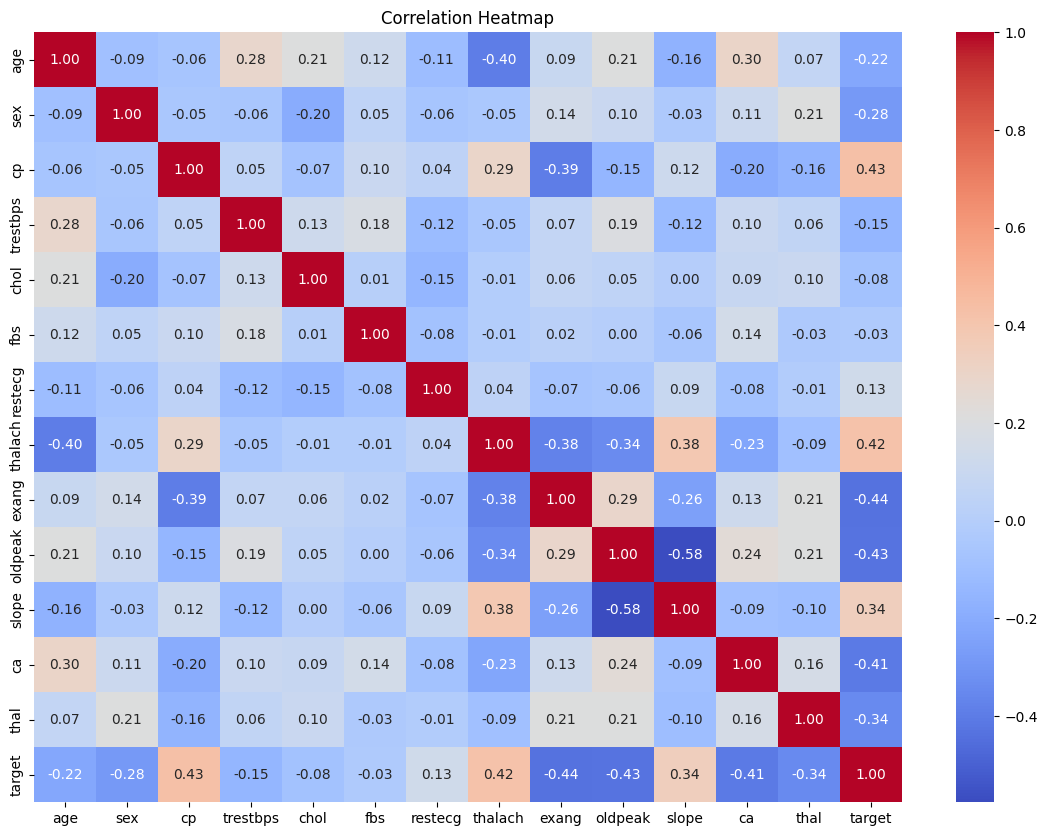

In [79]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

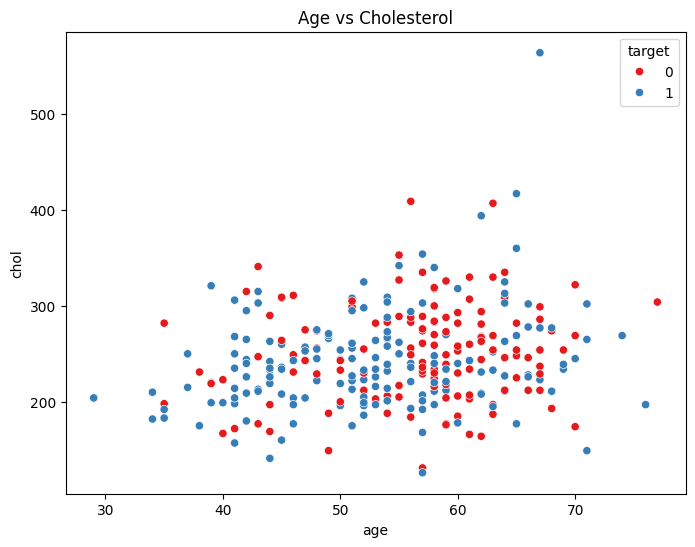

In [80]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='chol',
    hue='target',
    palette='Set1'
)

plt.title("Age vs Cholesterol")

plt.show()

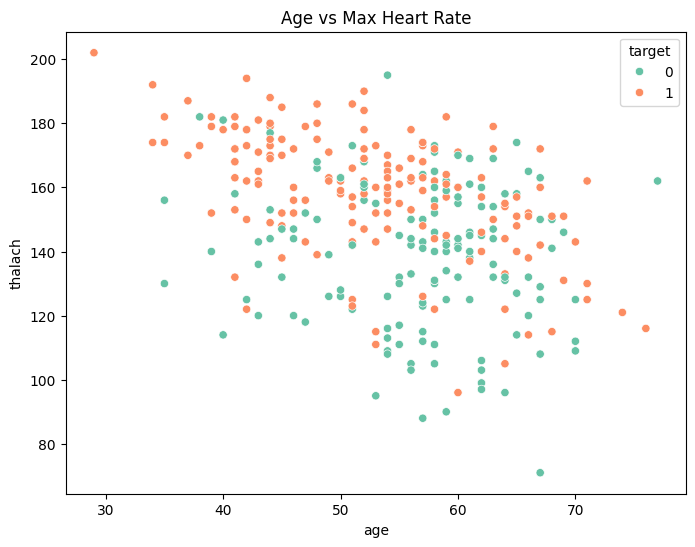

In [81]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='thalach',
    hue='target',
    palette='Set2'
)

plt.title("Age vs Max Heart Rate")

plt.show()

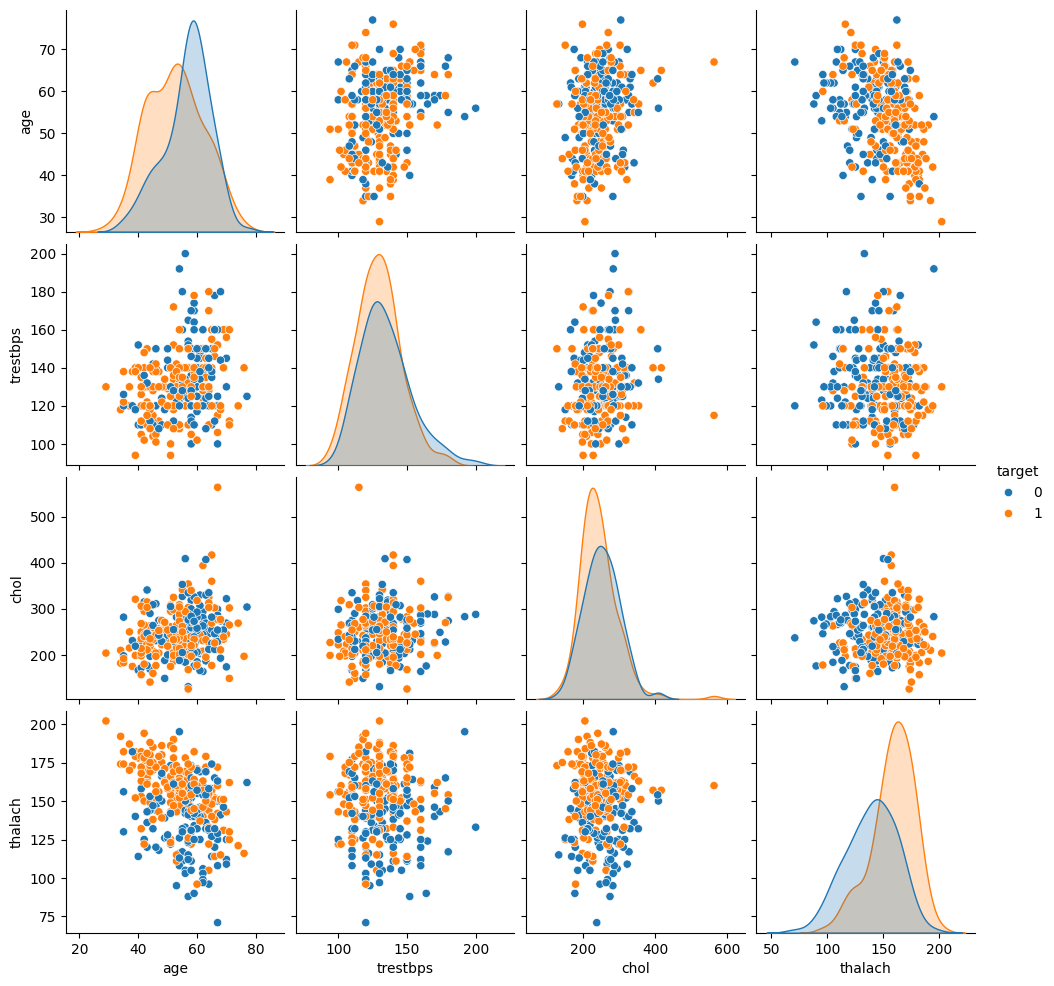

In [82]:
sns.pairplot(
    df[['age','trestbps','chol','thalach','target']],
    hue='target'
)

plt.show()

In [83]:
# ==========================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================

X = df.drop("target", axis=1)

y = df["target"]

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (302, 13)
Shape y : (302,)


In [84]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (241, 13)
Testing  : (61, 13)


In [85]:
# ==========================================
# STANDARD SCALER
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [86]:
# ==========================================
# RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [87]:
# ==========================================
# PREDIKSI
# ==========================================

y_pred = model.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 75.41 %


In [89]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision :", precision_score(y_test,y_pred))
print("Recall    :", recall_score(y_test,y_pred))
print("F1 Score  :", f1_score(y_test,y_pred))

Precision : 0.7647058823529411
Recall    : 0.7878787878787878
F1 Score  : 0.7761194029850746


In [90]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



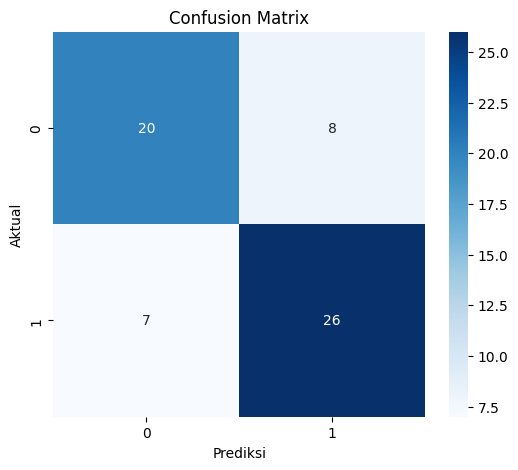

In [91]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

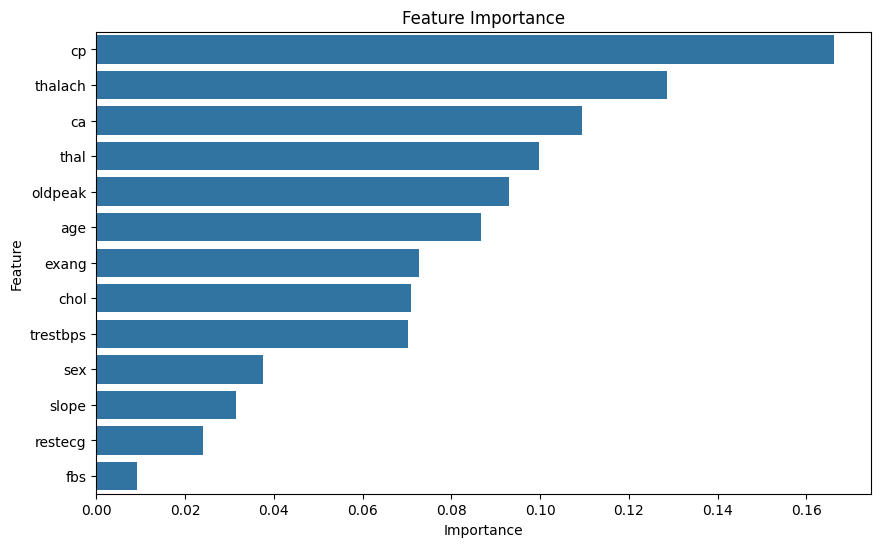

In [92]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [93]:
import joblib

joblib.dump(model, "heart_model.pkl")

print("Model berhasil disimpan.")

Model berhasil disimpan.


Unsupervised Learning

In [94]:
# ==========================================
# MENYIAPKAN DATA UNTUK CLUSTERING
# ==========================================

# Menghapus kolom target
X_cluster = df.drop("target", axis=1)

print("Jumlah Data :", X_cluster.shape[0])
print("Jumlah Fitur :", X_cluster.shape[1])

X_cluster.head()

Jumlah Data : 302
Jumlah Fitur : 13


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


Pada tahap ini dilakukan persiapan data untuk proses clustering. Kolom target dihapus karena metode Unsupervised Learning tidak menggunakan label kelas. Clustering hanya memanfaatkan atribut-atribut pasien untuk menemukan pola atau kelompok yang memiliki karakteristik serupa.

In [95]:
# ==========================================
# STANDARDISASI DATA
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print(X_scaled.shape)

(302, 13)


Standardisasi dilakukan agar seluruh fitur berada pada skala yang sama. Hal ini penting karena algoritma K-Means menggunakan perhitungan jarak Euclidean sehingga fitur dengan nilai yang lebih besar tidak mendominasi proses clustering.

In [96]:
# ==========================================
# ELBOW METHOD
# ==========================================

from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

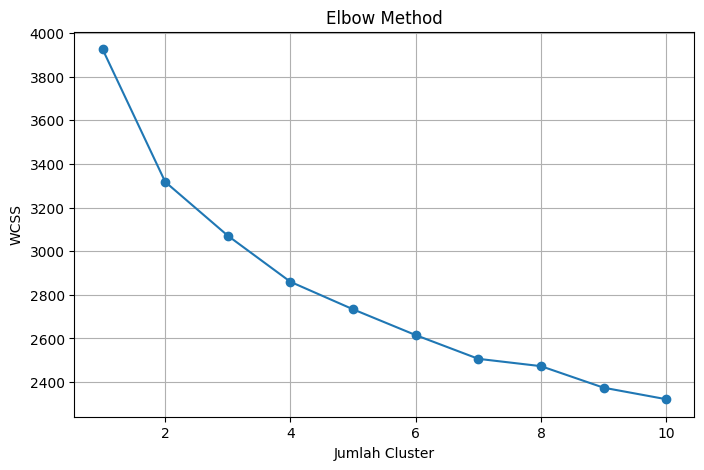

In [97]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Jumlah Cluster")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

Elbow Method digunakan untuk menentukan jumlah cluster yang optimal. Nilai WCSS (Within Cluster Sum of Squares) akan terus menurun seiring bertambahnya jumlah cluster. Titik siku (elbow) menunjukkan jumlah cluster terbaik yang memberikan keseimbangan antara kompleksitas model dan kualitas pengelompokan.

Catatan: Lihat grafik yang muncul. Jika siku berada pada angka 3, maka gunakan K = 3. Jika berada pada angka 4, gunakan K = 4, dan seterusnya.

In [98]:
# ==========================================
# MEMBANGUN MODEL K-MEANS
# ==========================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_scaled)

cluster

array([2, 0, 0, 2, 3, 1, 0, 0, 2, 0, 1, 0, 2, 0, 3, 1, 0, 1, 3, 2, 1, 0,
       1, 1, 0, 2, 3, 3, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 1, 2, 2,
       3, 1, 3, 3, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 3, 2, 3, 0, 2, 0, 0, 0,
       3, 2, 3, 2, 3, 0, 2, 2, 2, 2, 1, 0, 3, 1, 1, 3, 1, 1, 0, 2, 1, 1,
       3, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 3, 0, 0, 2, 0, 3, 0, 1, 1, 2, 2,
       1, 3, 1, 2, 0, 1, 0, 2, 2, 0, 1, 2, 3, 2, 2, 2, 3, 2, 1, 2, 0, 2,
       2, 0, 1, 2, 1, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 3, 0, 2, 2, 3,
       0, 2, 2, 1, 0, 2, 2, 3, 0, 2, 0, 0, 1, 2, 2, 1, 3, 2, 0, 1, 1, 2,
       1, 3, 3, 2, 1, 0, 0, 1, 2, 2, 2, 2, 0, 2, 3, 2, 2, 1, 2, 2, 1, 2,
       1, 1, 1, 1, 0, 3, 0, 2, 1, 2, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       2, 1, 0, 2, 0, 1, 3, 3, 1, 0, 1, 3, 2, 0, 3, 2, 2, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 3, 2, 3, 1, 1, 0, 1, 2, 2, 0, 1, 0, 2, 2, 0, 1, 0, 1,
       2, 0, 2, 2, 2, 0, 1, 0, 0, 1, 1, 2, 2, 3, 1, 3, 2, 2, 0, 1, 0, 0,
       2, 1, 3, 0, 2, 1, 1, 2, 3, 3, 2, 1, 2, 2, 1,

Implementasi Algoritma K-Means

Setelah jumlah cluster optimal diperoleh menggunakan Elbow Method, langkah selanjutnya adalah membangun model K-Means Clustering. Pada penelitian ini digunakan 4 cluster karena merupakan jumlah cluster yang memberikan keseimbangan terbaik antara kualitas pengelompokan dan kompleksitas model.

Algoritma K-Means bekerja dengan mengelompokkan data berdasarkan kedekatan jarak antar data menggunakan Euclidean Distance.

In [99]:
# ==========================================
# MENAMBAHKAN LABEL CLUSTER
# ==========================================

df_cluster = df.copy()

df_cluster["Cluster"] = cluster

df_cluster.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Cluster
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,2
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,2
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,3


Menambahkan Label Cluster

Setelah proses clustering selesai, setiap data pasien memperoleh label cluster. Label ini menunjukkan kelompok pasien berdasarkan karakteristik kesehatan yang memiliki kemiripan satu sama lain.

In [100]:
# ==========================================
# JUMLAH DATA SETIAP CLUSTER
# ==========================================

df_cluster["Cluster"].value_counts().sort_index()

,count
Cluster,
0,86
1,69
2,107
3,40


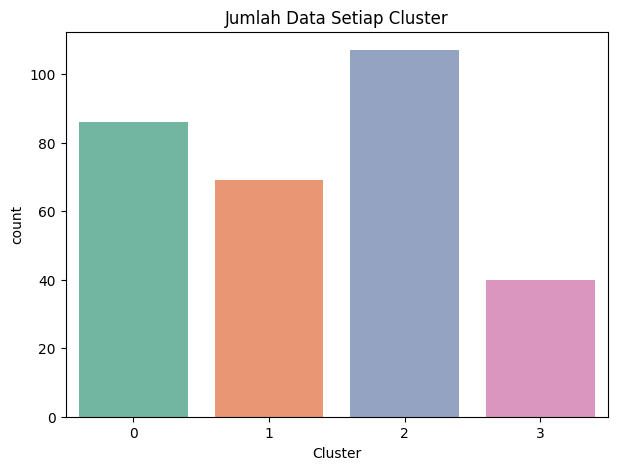

In [101]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Cluster",
    data=df_cluster,
    palette="Set2"
)

plt.title("Jumlah Data Setiap Cluster")

plt.show()

Distribusi Cluster

Grafik di atas menunjukkan jumlah anggota pada masing-masing cluster. Distribusi ini memberikan gambaran apakah hasil clustering cukup seimbang atau terdapat cluster yang memiliki anggota jauh lebih banyak dibandingkan cluster lainnya.

In [102]:
# ==========================================
# SILHOUETTE SCORE
# ==========================================

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    X_scaled,
    cluster
)

print("Silhouette Score :", round(sil_score,3))

Silhouette Score : 0.12


In [103]:
# ==========================================
# DAVIES BOULDIN INDEX
# ==========================================

from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(
    X_scaled,
    cluster
)

print("Davies Bouldin Index :", round(dbi,3))

Davies Bouldin Index : 2.131


Evaluasi Clustering

Kualitas clustering dievaluasi menggunakan dua metrik, yaitu:

Silhouette Score, dimana nilai yang semakin mendekati 1 menunjukkan kualitas cluster yang semakin baik.
Davies-Bouldin Index (DBI), dimana nilai yang semakin kecil menunjukkan pemisahan cluster yang semakin baik.

Dengan menggunakan kedua metrik tersebut, kualitas hasil clustering dapat dinilai secara objektif.

In [104]:
# ==========================================
# PCA
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_component = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    principal_component,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = cluster

pca_df.head()

,PC1,PC2,Cluster
0,-0.403727,-1.152038,2
1,2.614955,-0.600532,0
2,3.110398,-1.303946,0
3,-0.392439,-0.322416,2
4,2.255588,1.971414,3


Principal Component Analysis (PCA)

Karena dataset memiliki banyak fitur, maka digunakan Principal Component Analysis (PCA) untuk mereduksi dimensi data menjadi dua komponen utama sehingga hasil clustering dapat divisualisasikan dengan lebih mudah.

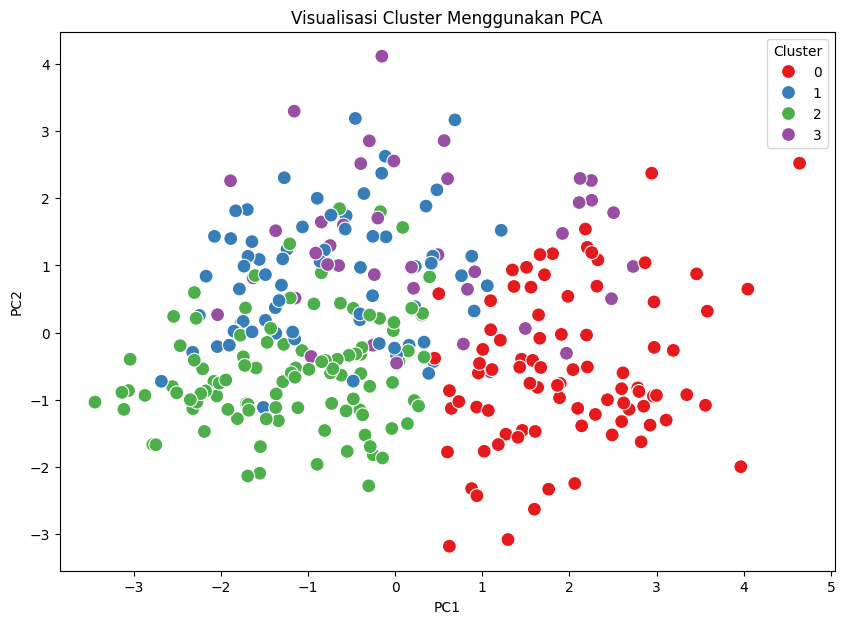

In [105]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Visualisasi Cluster Menggunakan PCA")

plt.show()

Visualisasi Hasil Clustering

Grafik PCA memperlihatkan hasil pengelompokan pasien ke dalam empat cluster. Setiap warna menunjukkan cluster yang berbeda sehingga dapat diamati bagaimana distribusi data dan tingkat pemisahan antar cluster.

In [106]:
# ==========================================
# RATA-RATA MASING-MASING CLUSTER
# ==========================================

cluster_summary = df_cluster.groupby("Cluster").mean()

cluster_summary

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
Cluster,,,,,,,,,,,,,,
0,57.825581,0.825581,0.255814,133.674419,254.139535,0.046512,0.441860,128.720930,0.732558,2.077907,0.941860,1.290698,2.604651,0.104651
1,56.478261,0.057971,1.202899,131.927536,258.971014,0.000000,0.536232,151.565217,0.144928,0.560870,1.507246,0.260870,2.000000,0.898551
2,49.102804,0.943925,1.242991,127.009346,232.467290,0.009346,0.616822,164.598131,0.130841,0.577570,1.691589,0.392523,2.336449,0.663551
3,57.775000,0.750000,1.325000,138.875000,246.100000,1.000000,0.450000,150.750000,0.300000,0.895000,1.400000,1.150000,2.175000,0.550000


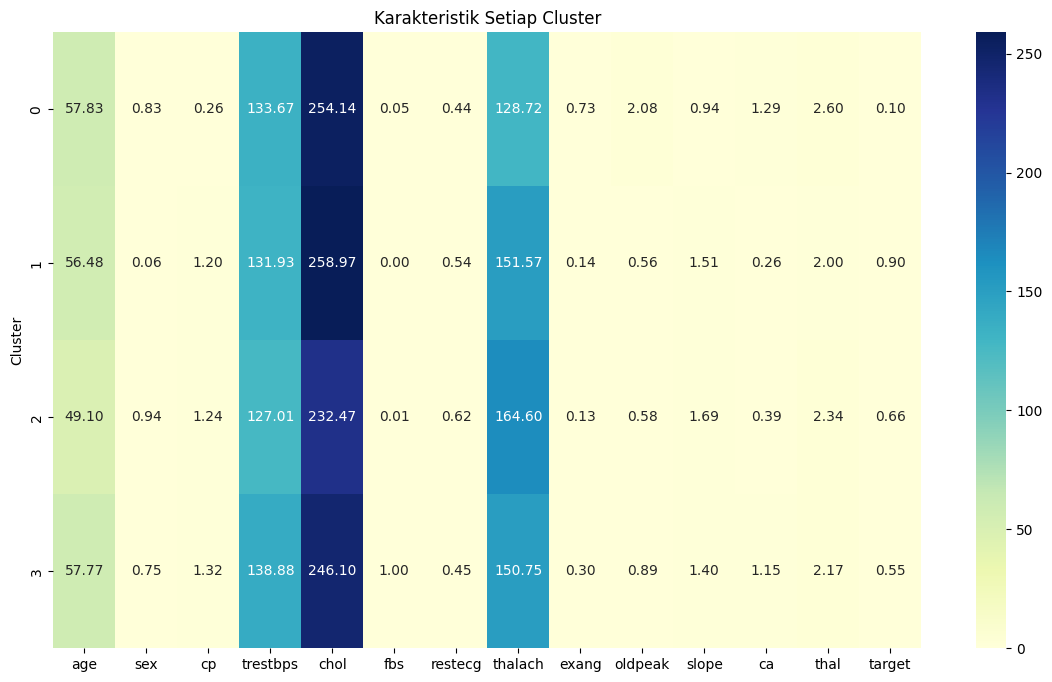

In [107]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Karakteristik Setiap Cluster")

plt.show()

Analisis Karakteristik Cluster

Tabel dan heatmap di atas menunjukkan nilai rata-rata setiap fitur pada masing-masing cluster. Berdasarkan hasil tersebut dapat dilakukan interpretasi mengenai karakteristik setiap kelompok pasien, misalnya kelompok dengan rata-rata usia tinggi, kolesterol tinggi, atau denyut jantung maksimum yang lebih rendah.

Interpretasi ini dapat digunakan sebagai dasar dalam memahami profil kesehatan pasien berdasarkan hasil clustering.

Kesimpulan

Berdasarkan hasil implementasi algoritma K-Means, diperoleh 4 cluster sebagai jumlah cluster optimal berdasarkan Elbow Method. Evaluasi menggunakan Silhouette Score dan Davies-Bouldin Index menunjukkan bahwa model mampu mengelompokkan pasien berdasarkan karakteristik kesehatannya dengan cukup baik.

Visualisasi menggunakan PCA memperlihatkan adanya pemisahan antar cluster sehingga karakteristik masing-masing kelompok dapat dianalisis lebih lanjut. Hasil clustering ini dapat dimanfaatkan untuk membantu identifikasi kelompok pasien yang memiliki profil kesehatan serupa sehingga dapat mendukung pengambilan keputusan dalam bidang kesehatan.